### Taking same dataset which i took in RandomForest to check accuracy of AdaBoost Model as comapre to RandomForest.

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings

warnings.filterwarnings("ignore")

%matplotlib inline

In [60]:
df=pd.read_csv("Travel.csv")
df.head()

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,NaN,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


## Data cleaning
### Handling missing values
#### 1.Handling Missing values
#### 2.Handling duplicates
#### 3.Check Data type
#### 4.Understand the dataset  

In [3]:
df.isnull().sum()

CustomerID                    0
ProdTaken                     0
Age                         226
TypeofContact                25
CityTier                      0
DurationOfPitch             251
Occupation                    0
Gender                        0
NumberOfPersonVisiting        0
NumberOfFollowups            45
ProductPitched                0
PreferredPropertyStar        26
MaritalStatus                 0
NumberOfTrips               140
Passport                      0
PitchSatisfactionScore        0
OwnCar                        0
NumberOfChildrenVisiting     66
Designation                   0
MonthlyIncome               233
dtype: int64

In [4]:
## check all the categories
df['Gender'].value_counts()

Gender
Male       2916
Female     1817
Fe Male     155
Name: count, dtype: int64

In [5]:
df['MaritalStatus'].value_counts()

MaritalStatus
Married      2340
Divorced      950
Single        916
Unmarried     682
Name: count, dtype: int64

In [6]:
df['TypeofContact'].value_counts()

TypeofContact
Self Enquiry       3444
Company Invited    1419
Name: count, dtype: int64

In [7]:
df['Gender']=df['Gender'].replace('Fe Male','Female')
df['MaritalStatus']=df['MaritalStatus'].replace('Single','Unmarried')

In [8]:
df.head()

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Unmarried,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Unmarried,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,NaN,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


In [9]:
## Checking Missing values
## these are the features with nan value
features_with_na=[features for features in df.columns if df[features].isnull().sum()>=1]
for feature in features_with_na:
    print(feature,np.round(df[feature].isnull().mean()*100,5),'% missing vaules')

Age 4.62357 % missing vaules
TypeofContact 0.51146 % missing vaules
DurationOfPitch 5.13502 % missing vaules
NumberOfFollowups 0.92062 % missing vaules
PreferredPropertyStar 0.53191 % missing vaules
NumberOfTrips 2.86416 % missing vaules
NumberOfChildrenVisiting 1.35025 % missing vaules
MonthlyIncome 4.76678 % missing vaules


In [10]:
## Sataistics  on numerical coulnms(Null cols)
df[features_with_na].select_dtypes(exclude='object').describe()

,Age,DurationOfPitch,NumberOfFollowups,PreferredPropertyStar,NumberOfTrips,NumberOfChildrenVisiting,MonthlyIncome
count,4662.000000,4637.000000,4843.000000,4862.000000,4748.000000,4822.000000,4655.000000
mean,37.622265,15.490835,3.708445,3.581037,3.236521,1.187267,23619.853491
std,9.316387,8.519643,1.002509,0.798009,1.849019,0.857861,5380.698361
min,18.000000,5.000000,1.000000,3.000000,1.000000,0.000000,1000.000000
25%,31.000000,9.000000,3.000000,3.000000,2.000000,1.000000,20346.000000
50%,36.000000,13.000000,4.000000,3.000000,3.000000,1.000000,22347.000000
75%,44.000000,20.000000,4.000000,4.000000,4.000000,2.000000,25571.000000
max,61.000000,127.000000,6.000000,5.000000,22.000000,3.000000,98678.000000


### Impute null values 
#### 1.Impute median vaules for Age colunm 
#### 2.Impute Mode for Type of Contract 
#### 3.Impute Median for duration of pitch
#### 4.Impute mode for numberofFollowup as it is Discrete feature
#### 5.Impute Mode for PreferredPropertyStar
#### 6.Impute Mode for NumberOfTrips
#### 7.Impute Mode for NumberOfChildrenVisiting
#### 8.Impute Medeain for MonthlyIncome

In [11]:
#Age
df.Age.fillna(df.Age.median(),inplace=True)

#TypeContract
df.TypeofContact.fillna(df.TypeofContact.mode()[0],inplace=True)

#DurationOfPitch
df.DurationOfPitch.fillna(df.DurationOfPitch.median(),inplace=True)

#NumberOfFollowups
df.NumberOfFollowups.fillna(df.NumberOfFollowups.mode()[0],inplace=True)

#PreferedPropertyStar
df.PreferredPropertyStar.fillna(df.PreferredPropertyStar.mode()[0],inplace=True)

##NumberOfTrips
df.NumberOfTrips.fillna(df.NumberOfTrips.median(),inplace=True)

#NumberOfChildrenVisting
df.NumberOfChildrenVisiting.fillna(df.NumberOfChildrenVisiting.mode()[0],inplace=True)

#MonthlyIncome

df.MonthlyIncome.fillna(df.MonthlyIncome.median(),inplace=True)

In [12]:
df.head()
df.isnull().sum()

CustomerID                  0
ProdTaken                   0
Age                         0
TypeofContact               0
CityTier                    0
DurationOfPitch             0
Occupation                  0
Gender                      0
NumberOfPersonVisiting      0
NumberOfFollowups           0
ProductPitched              0
PreferredPropertyStar       0
MaritalStatus               0
NumberOfTrips               0
Passport                    0
PitchSatisfactionScore      0
OwnCar                      0
NumberOfChildrenVisiting    0
Designation                 0
MonthlyIncome               0
dtype: int64

In [13]:
##custmoerid is not important 
df.drop('CustomerID',inplace=True,axis=1)

### Feature Engineering
#### Feature Extravtion

In [14]:
##create a new colunm for feature
df['TotalVisiting']=df['NumberOfPersonVisiting']+df['NumberOfChildrenVisiting']
df.drop(columns=['NumberOfPersonVisiting','NumberOfChildrenVisiting'],axis=1,inplace=True)

In [15]:
## get all the numeric feature
num_features=[feature for feature in df.columns if df[feature].dtypes!='O']
print('Num of Numerical Features:',len(num_features))

Num of Numerical Features: 12


In [16]:
## get all the categoriocal features
cat_features=[feature for feature in df.columns if df[feature].dtypes=='O']
print('Num of Categorical Features:',len(cat_features))

Num of Categorical Features: 6


In [17]:
## Discrete features
discrete_features=[feature for feature in num_features if len(df[feature].unique())<=25]
print('Num of Discrete Features:',len(discrete_features))

Num of Discrete Features: 9


In [18]:
## Continuous features
continuous_features=[feature for feature in num_features if feature not in discrete_features]
print('Num of Continuous Features:',len(continuous_features))

Num of Continuous Features: 3


In [19]:
df.head()

,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,Designation,MonthlyIncome,TotalVisiting
0,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3.0,Deluxe,3.0,Unmarried,1.0,1,2,1,Manager,20993.0,3.0
1,0,49.0,Company Invited,1,14.0,Salaried,Male,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,Manager,20130.0,5.0
2,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,4.0,Basic,3.0,Unmarried,7.0,1,3,0,Executive,17090.0,3.0
3,0,33.0,Company Invited,1,9.0,Salaried,Female,3.0,Basic,3.0,Divorced,2.0,1,5,1,Executive,17909.0,3.0
4,0,36.0,Self Enquiry,1,8.0,Small Business,Male,3.0,Basic,4.0,Divorced,1.0,0,5,1,Executive,18468.0,2.0


In [20]:
X = df.drop('ProdTaken', axis=1)
y = df['ProdTaken']

In [21]:
categorical_cols = [
    'TypeofContact',
    'Occupation',
    'Gender',
    'ProductPitched',
    'MaritalStatus'
]

ordinal_cols = [
    'Designation',
    'CityTier',
    'PreferredPropertyStar'
]

numerical_cols = [
    col for col in X.columns if col not in categorical_cols + ordinal_cols
]

### Train Test Split And Model Training

In [22]:
from sklearn.model_selection import train_test_split
X=df.drop(['ProdTaken'],axis=1)
y=df['ProdTaken']

In [23]:
y.value_counts()

ProdTaken
0    3968
1     920
Name: count, dtype: int64

In [24]:
X.head()

,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,Designation,MonthlyIncome,TotalVisiting
0,41.0,Self Enquiry,3,6.0,Salaried,Female,3.0,Deluxe,3.0,Unmarried,1.0,1,2,1,Manager,20993.0,3.0
1,49.0,Company Invited,1,14.0,Salaried,Male,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,Manager,20130.0,5.0
2,37.0,Self Enquiry,1,8.0,Free Lancer,Male,4.0,Basic,3.0,Unmarried,7.0,1,3,0,Executive,17090.0,3.0
3,33.0,Company Invited,1,9.0,Salaried,Female,3.0,Basic,3.0,Divorced,2.0,1,5,1,Executive,17909.0,3.0
4,36.0,Self Enquiry,1,8.0,Small Business,Male,3.0,Basic,4.0,Divorced,1.0,0,5,1,Executive,18468.0,2.0


In [25]:
## seperate dataset into train  and test
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
X_train.shape,X_test.shape

((3910, 17), (978, 17))

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4888 entries, 0 to 4887
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ProdTaken               4888 non-null   int64  
 1   Age                     4888 non-null   float64
 2   TypeofContact           4888 non-null   object 
 3   CityTier                4888 non-null   int64  
 4   DurationOfPitch         4888 non-null   float64
 5   Occupation              4888 non-null   object 
 6   Gender                  4888 non-null   object 
 7   NumberOfFollowups       4888 non-null   float64
 8   ProductPitched          4888 non-null   object 
 9   PreferredPropertyStar   4888 non-null   float64
 10  MaritalStatus           4888 non-null   object 
 11  NumberOfTrips           4888 non-null   float64
 12  Passport                4888 non-null   int64  
 13  PitchSatisfactionScore  4888 non-null   int64  
 14  OwnCar                  4888 non-null   

In [27]:
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(drop="first", sparse_output=False)

In [28]:
X_train_cat = ohe.fit_transform(X_train[categorical_cols])
X_test_cat = ohe.transform(X_test[categorical_cols])

X_train_cat

array([[1., 0., 0., ..., 0., 0., 1.],
       [1., 0., 1., ..., 0., 1., 0.],
       [1., 1., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 1., 0.],
       [0., 0., 1., ..., 0., 0., 0.]])

In [29]:
# Convert to DataFrame
cat_feature_names = ohe.get_feature_names_out(categorical_cols)

X_train_cat_df = pd.DataFrame(X_train_cat, columns=cat_feature_names)
X_test_cat_df = pd.DataFrame(X_test_cat, columns=cat_feature_names)

In [30]:
X_train_cat_df.head()

,TypeofContact_Self Enquiry,Occupation_Large Business,Occupation_Salaried,Occupation_Small Business,Gender_Male,ProductPitched_Deluxe,ProductPitched_King,ProductPitched_Standard,ProductPitched_Super Deluxe,MaritalStatus_Married,MaritalStatus_Unmarried
0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
1,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [31]:
from sklearn.preprocessing import OrdinalEncoder

ord_encoder = OrdinalEncoder()

X_train_ord = ord_encoder.fit_transform(X_train[ordinal_cols])
X_test_ord = ord_encoder.transform(X_test[ordinal_cols])

X_train_ord

array([[1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 2.],
       ...,
       [1., 2., 0.],
       [2., 2., 0.],
       [1., 0., 0.]])

In [32]:
# Convert to DataFrame
X_train_ord_df = pd.DataFrame(X_train_ord, columns=ordinal_cols)
X_test_ord_df = pd.DataFrame(X_test_ord, columns=ordinal_cols)

X_train_ord_df.head()

,Designation,CityTier,PreferredPropertyStar
0,1.0,0.0,0.0
1,1.0,0.0,0.0
2,1.0,0.0,2.0
3,2.0,0.0,0.0
4,1.0,0.0,0.0


In [33]:
designation_order = ["Executive", "Manager", "Senior Manager", "AVP", "VP"]

ord_encoder = OrdinalEncoder(categories=[
    designation_order,  # Designation
    [1, 2, 3],          # CityTier
    [1, 2, 3, 4, 5]     # PreferredPropertyStar
])

In [34]:
X_train_final = pd.concat([
    X_train[numerical_cols].reset_index(drop=True),
    X_train_ord_df.reset_index(drop=True),
    X_train_cat_df.reset_index(drop=True)
], axis=1)

X_test_final = pd.concat([
    X_test[numerical_cols].reset_index(drop=True),
    X_test_ord_df.reset_index(drop=True),
    X_test_cat_df.reset_index(drop=True)
], axis=1)

In [35]:
feature_names = list(X_train_final.columns)
feature_names

['Age',
 'DurationOfPitch',
 'NumberOfFollowups',
 'NumberOfTrips',
 'Passport',
 'PitchSatisfactionScore',
 'OwnCar',
 'MonthlyIncome',
 'TotalVisiting',
 'Designation',
 'CityTier',
 'PreferredPropertyStar',
 'TypeofContact_Self Enquiry',
 'Occupation_Large Business',
 'Occupation_Salaried',
 'Occupation_Small Business',
 'Gender_Male',
 'ProductPitched_Deluxe',
 'ProductPitched_King',
 'ProductPitched_Standard',
 'ProductPitched_Super Deluxe',
 'MaritalStatus_Married',
 'MaritalStatus_Unmarried']

In [49]:
from sklearn.ensemble import AdaBoostClassifier

model = AdaBoostClassifier(n_estimators=100, random_state=42)

model.fit(X_train_final, y_train)

AdaBoostClassifier(n_estimators=100, random_state=42)

In [50]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = model.predict(X_test_final)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nReport:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix: \n", confusion_matrix(y_test, y_pred))

Accuracy: 0.8343558282208589

Report:
               precision    recall  f1-score   support

           0       0.84      0.98      0.91       787
           1       0.75      0.23      0.35       191

    accuracy                           0.83       978
   macro avg       0.79      0.61      0.63       978
weighted avg       0.82      0.83      0.80       978


Confusion Matrix: 
 [[772  15]
 [147  44]]


### Here, we trained model using smote but it is giving worse result then previous one

## Now let us use class_weight="balanced"

In [51]:
from sklearn.ensemble import AdaBoostClassifier

model2 = AdaBoostClassifier(
    n_estimators=100,
    random_state=42
)

model2.fit(X_train_final, y_train)

AdaBoostClassifier(n_estimators=100, random_state=42)

In [52]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = model2.predict(X_test_final)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nReport:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.8343558282208589

Report:
               precision    recall  f1-score   support

           0       0.84      0.98      0.91       787
           1       0.75      0.23      0.35       191

    accuracy                           0.83       978
   macro avg       0.79      0.61      0.63       978
weighted avg       0.82      0.83      0.80       978


Confusion Matrix:
 [[772  15]
 [147  44]]


In [53]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

In [54]:
y_prob = model.predict_proba(X_test_final)[:, 1]

In [55]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

In [56]:
auc_score = roc_auc_score(y_test, y_prob)
print("ROC-AUC Score:", auc_score)

ROC-AUC Score: 0.8027002933799903


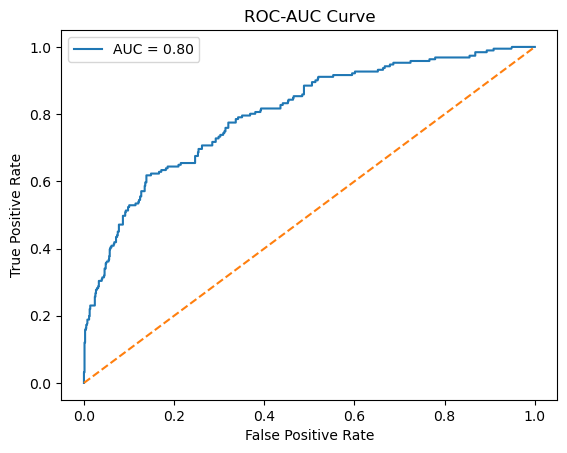

In [57]:
plt.figure()

plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--")  # random model line

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Curve")
plt.legend()

plt.show()

In [58]:
importances = model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X_train_final.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(feature_importance.head(10))

                    Feature  Importance
4                  Passport    0.233132
0                       Age    0.126185
9               Designation    0.108152
8             TotalVisiting    0.085316
2         NumberOfFollowups    0.083224
3             NumberOfTrips    0.069200
22  MaritalStatus_Unmarried    0.048395
11    PreferredPropertyStar    0.041172
10                 CityTier    0.037327
7             MonthlyIncome    0.033856


##### So we can see that we got Accuracy score :0.8343 and ROC-AUC Score: 0.8027 which is less than RandomForest. In RandomForest we got Accuracy: 0.9171 and ROC-AUC Score: 0.9801.